In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\dparh\Documents\GitHub\goit-project-final\internet_service_churn.csv")

df.head(5)

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [7]:
df.drop(columns=['id'],inplace=True)

df.describe()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [8]:
df.isnull().sum()

is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             21572
service_failure_count              0
download_avg                     381
upload_avg                       381
download_over_limit                0
churn                              0
dtype: int64

In [9]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No missing values found in the dataset.")
else:
    missing_df = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing / len(df) * 100
    })
    display(missing_df)

    print("\nMissing values by churn class:")
    display(df[missing.index].isna().groupby(df["churn"]).sum())

    print("\nSample rows with missing values:")
    display(df[df[missing.index].isna().any(axis=1)].head(10))

,missing_count,missing_pct
reamining_contract,21572,29.847525
download_avg,381,0.527161
upload_avg,381,0.527161



Missing values by churn class:


,reamining_contract,download_avg,upload_avg
churn,,,
0,1853,381,381
1,19719,0,0



Sample rows with missing values:


,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
1,0,0,8.22,0,NaN,0,0.0,0.0,0,1
3,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,0,0,6.39,0,NaN,0,0.0,0.0,0,1
7,0,0,5.48,14,NaN,1,0.0,0.0,0,1
8,0,0,8.54,0,NaN,0,0.0,0.0,0,1
9,0,0,8.33,0,NaN,0,0.0,0.0,0,1
12,0,0,6.64,10,NaN,0,0.0,0.0,0,1
13,0,0,5.53,14,NaN,0,0.0,0.0,0,1
17,0,0,6.45,40,NaN,0,0.0,0.0,0,1
18,0,0,6.81,14,NaN,0,0.0,0.0,0,1


### The trickiest part is to pre-process the "remaining_contract" column correctly

If we fill it with a mean of the entire column, we could skew the results by doing that, which is not optimal especially in the case of classification model. 30% is a large chunk of data, so we should be careful with this.

In [10]:
print("Users with active subscription: ", int((df['churn'] == 0).sum()))
print("Users with an active subscription: " , int((df['churn'] == 1).sum()))

Users with active subscription:  32224
Users with an active subscription:  40050


### Distribution of quantitative features

In [11]:
df.groupby('churn').mean()

,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit
churn,,,,,,,,,
0,0.956989,0.496214,2.727828,19.252731,1.072765,0.254593,64.884728,5.983563,0.031622
1,0.701223,0.204619,2.226554,18.692859,0.183152,0.290037,26.838312,2.767698,0.349213


In [12]:
# show churn rates for categorical-like columns (object/category, boolean, or with few unique values)
exclude = {'id', 'churn'}
cat_cols = [c for c in df.columns if c not in exclude and (df[c].dtype == 'object' or df[c].dtype.name == 'category' or df[c].nunique() <= 10)]

if not cat_cols:
    print("No categorical-like columns found.")
else:
    for c in cat_cols:
        print(f'Churn rate by {c} (unique={df[c].nunique()}):')
        print(df.groupby(c)['churn'].agg(['mean','count']).sort_values('mean', ascending=False))
        print()

Churn rate by is_tv_subscriber (unique=2):
                      mean  count
is_tv_subscriber                 
0                 0.896195  13352
1                 0.476630  58922

Churn rate by is_movie_package_subscriber (unique=2):
                                 mean  count
is_movie_package_subscriber                 
0                            0.662418  48089
1                            0.338846  24185

Churn rate by download_over_limit (unique=8):
                         mean  count
download_over_limit                 
7                    0.998016    504
6                    0.962209    688
4                    0.929825    456
5                    0.925408    429
3                    0.895582    498
2                    0.812500    560
1                    0.736292    766
0                    0.535284  68373



Churn rate when download_over_limit=0: 0.535
Churn rate when download_over_limit=1: 0.736


C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\524626854.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=rates, palette='Blues_d')


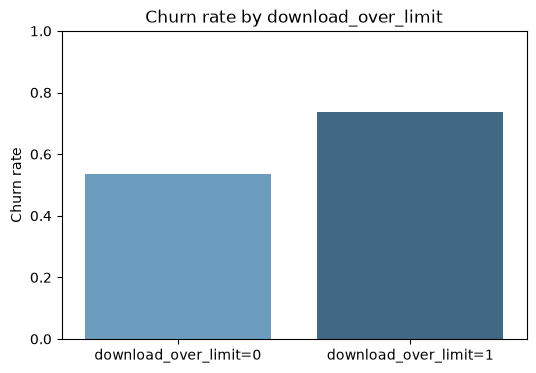

In [13]:
# Check if downloading over limit affects churn rate
download_over_limit_churn_0 = df[df['download_over_limit'] == 0]['churn'].mean()
download_over_limit_churn_1 = df[df['download_over_limit'] == 1]['churn'].mean()

print(f'Churn rate when download_over_limit=0: {download_over_limit_churn_0:.3f}')
print(f'Churn rate when download_over_limit=1: {download_over_limit_churn_1:.3f}')

rates = [download_over_limit_churn_0, download_over_limit_churn_1]
labels = ['download_over_limit=0', 'download_over_limit=1']

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=rates, palette='Blues_d')
plt.title('Churn rate by download_over_limit')
plt.ylabel('Churn rate')
plt.ylim(0, 1)
plt.show()

This may indicate that customers that cancel their subscriptions may be unsatisfied with downloading limits

C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\404746517.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


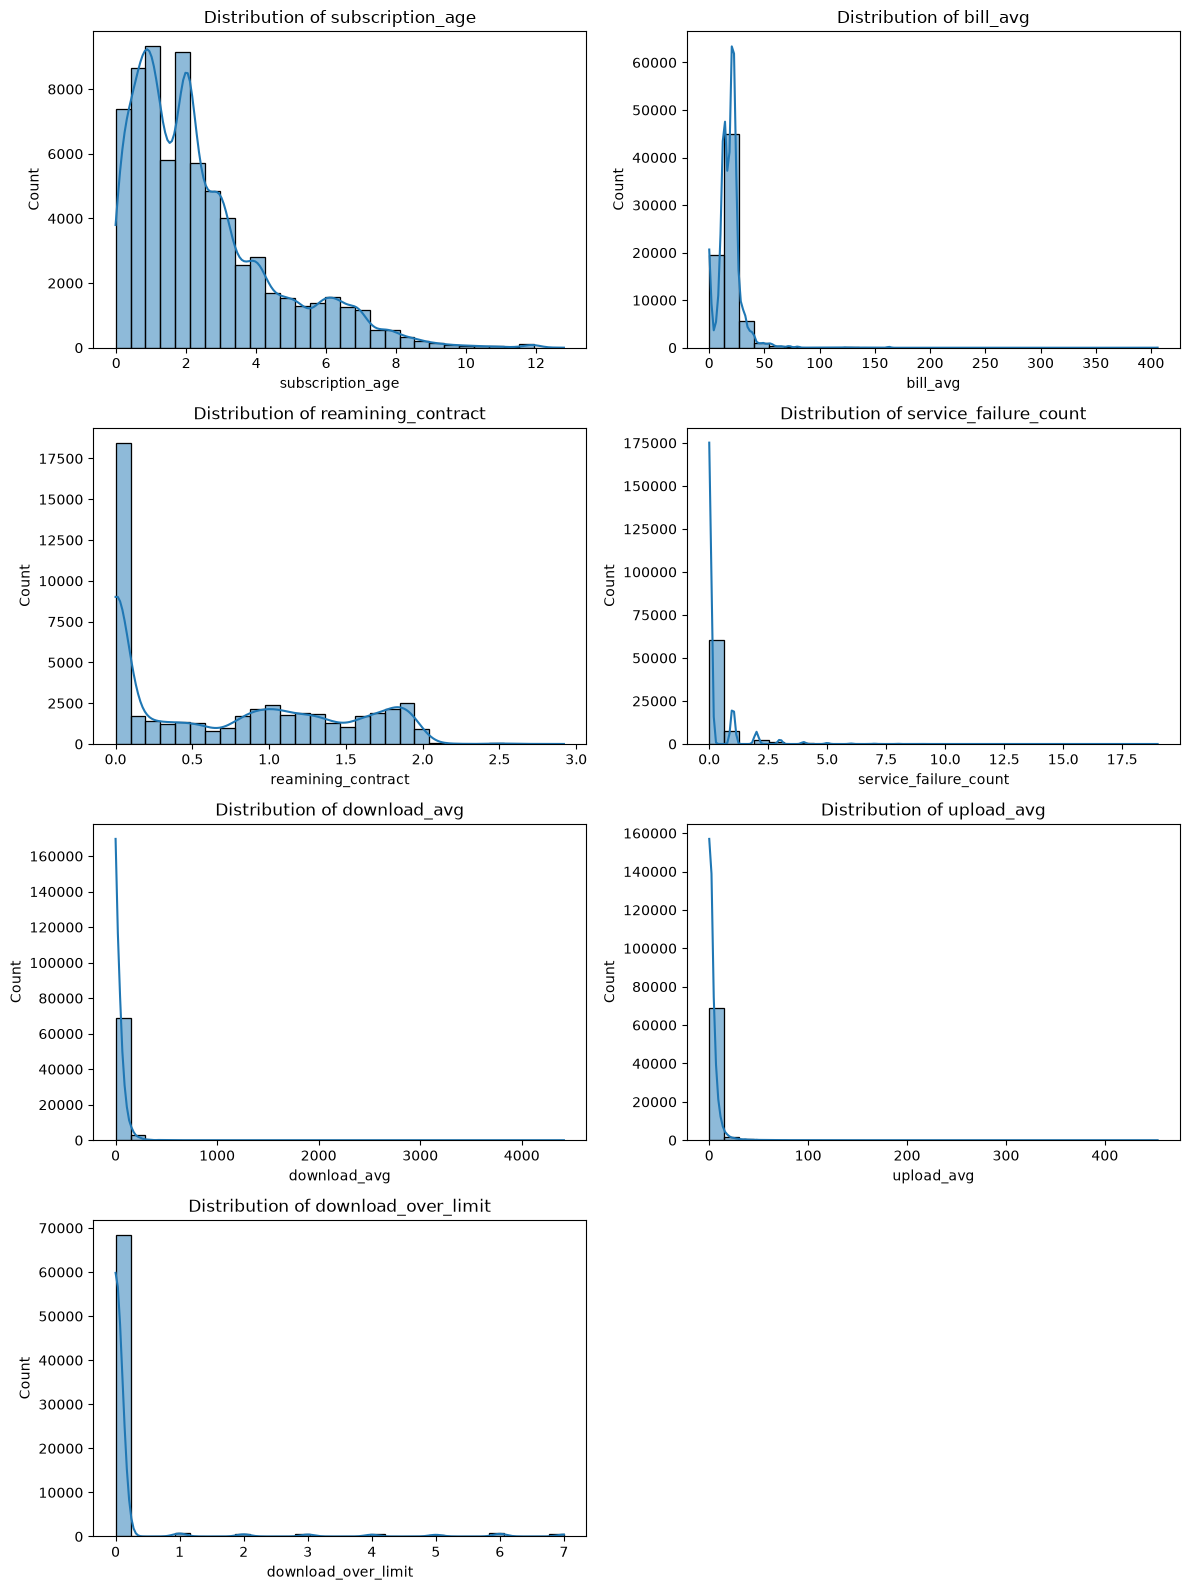

In [14]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['id', 'churn'], errors='ignore').columns
non_binary_numeric = [c for c in numeric_cols if df[c].nunique(dropna=False) > 2]

n_cols = 2
n_rows = int(np.ceil(len(non_binary_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), constrained_layout=True)
axes = axes.flatten()

for ax, column in zip(axes, non_binary_numeric):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Count')

for ax in axes[len(non_binary_numeric):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Investigate missing columns

### Correlation matrix

<Axes: >

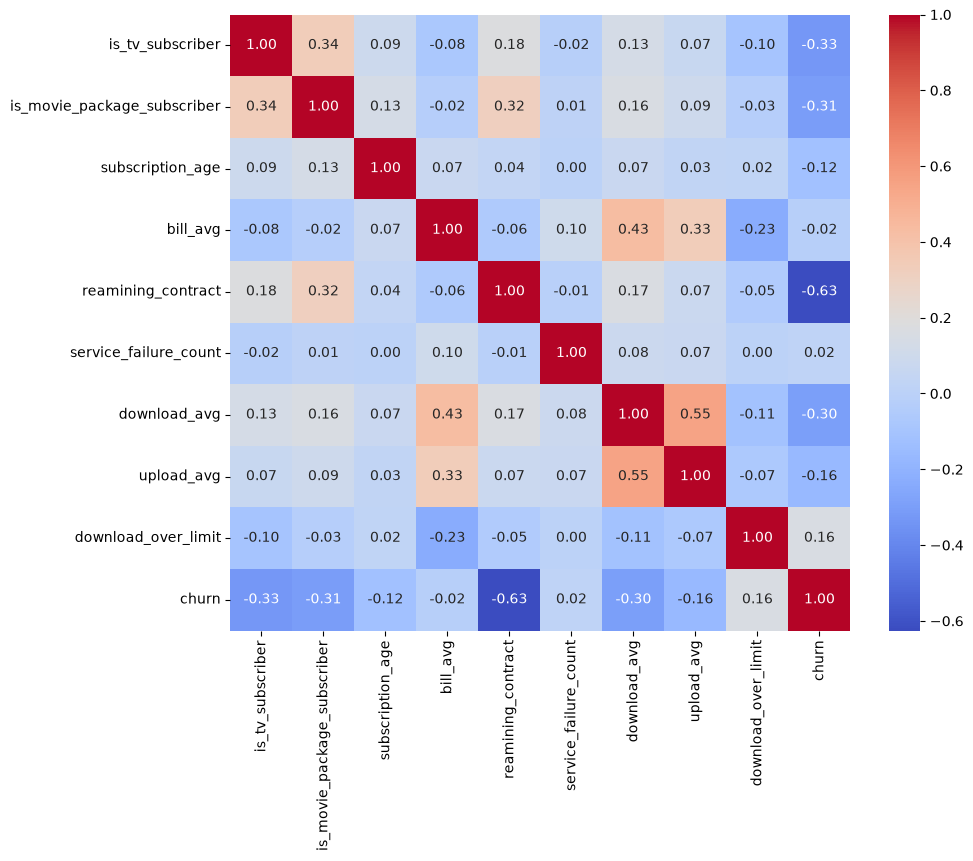

In [15]:
mtx = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(mtx, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

### Interpretation of matrix

* (remaining_contract | churn) = -0.63 -> Perhaps the strongest indicator that determines whether the user will stay within the platform or not
* ()

### First option. Fill with averages and ee how it affects the correlation

<Axes: >

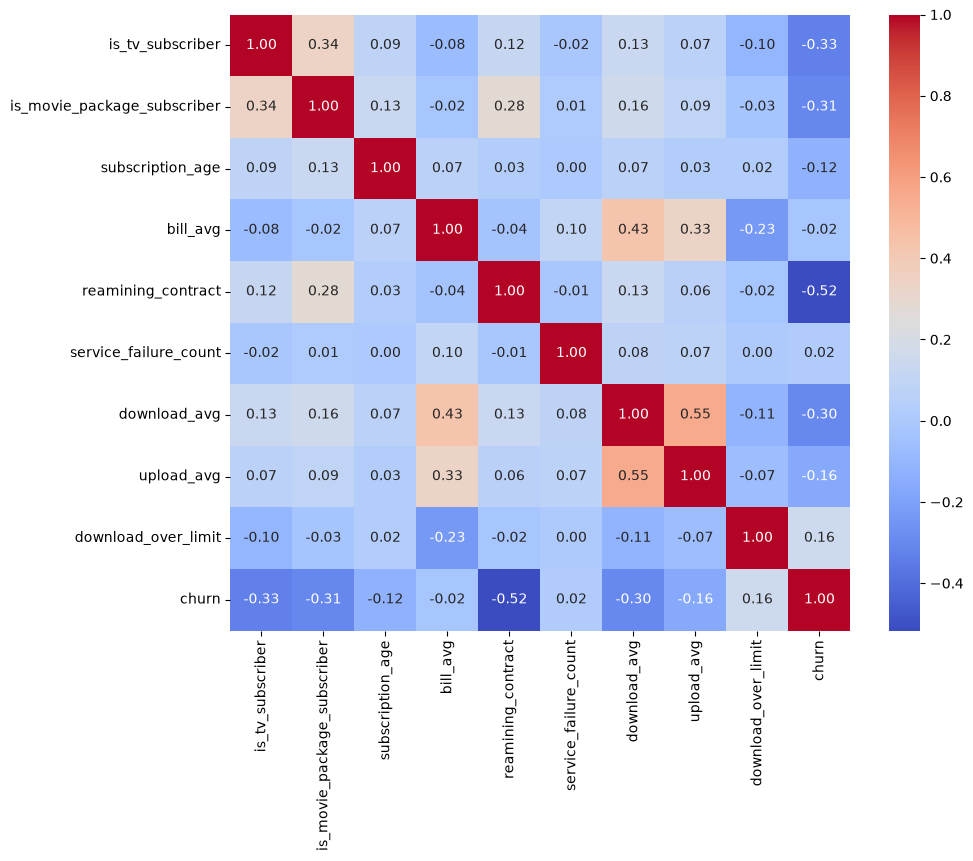

In [16]:
df['reamining_contract'] = df['reamining_contract'].fillna(df['reamining_contract'].mean(), inplace=False)

mtx_means = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(mtx_means, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

### Scenario 2. Fill with zeros and see if it skews data the same way

<Axes: >

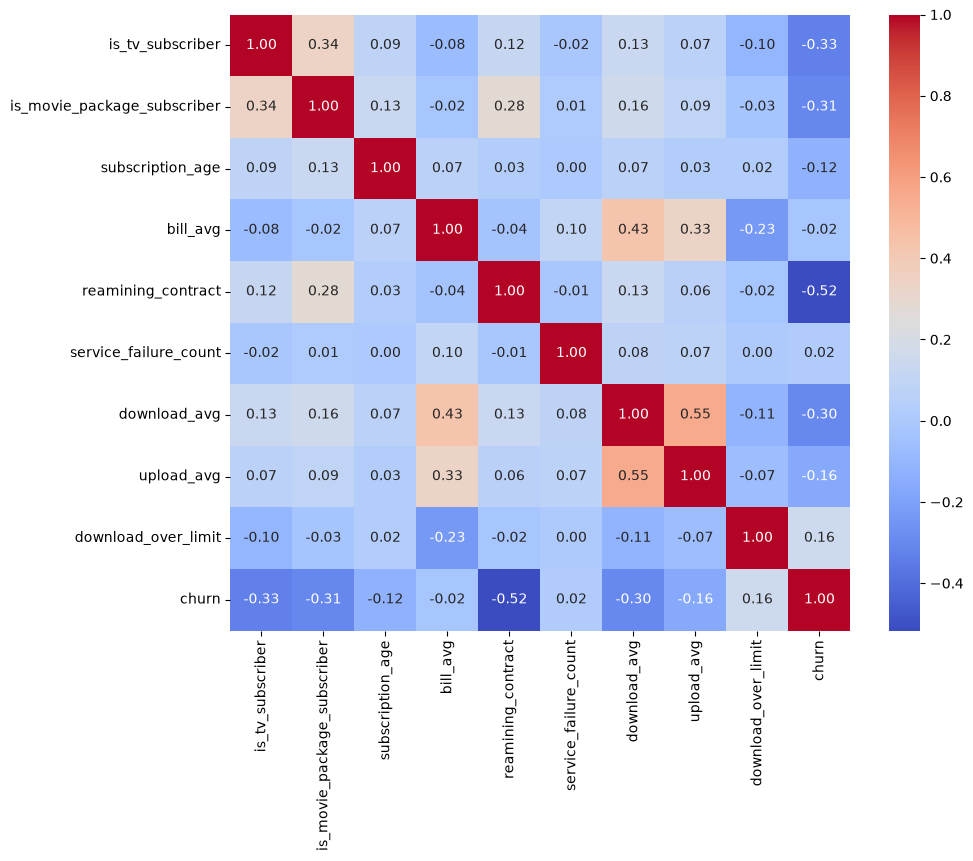

In [17]:
df['reamining_contract'] = df['reamining_contract'].fillna(0, inplace=False)

mtx_zeros = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(mtx_zeros, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

In [18]:
print(mtx)

                             is_tv_subscriber  is_movie_package_subscriber  \
is_tv_subscriber                     1.000000                     0.337435   
is_movie_package_subscriber          0.337435                     1.000000   
subscription_age                     0.087276                     0.131986   
bill_avg                            -0.076245                    -0.022534   
reamining_contract                   0.178814                     0.319179   
service_failure_count               -0.016041                     0.013345   
download_avg                         0.131650                     0.160590   
upload_avg                           0.065791                     0.093251   
download_over_limit                 -0.103546                    -0.026352   
churn                               -0.327582                    -0.307167   

                             subscription_age  bill_avg  reamining_contract  \
is_tv_subscriber                     0.087276 -0.076245       

### Outliers

C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\2072441576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='churn', y=column, ax=ax, inner='quartile', palette='muted')
C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\2072441576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='churn', y=column, ax=ax, inner='quartile', palette='muted')
C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\2072441576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='churn', y=column, ax=ax, inner='quartile', 

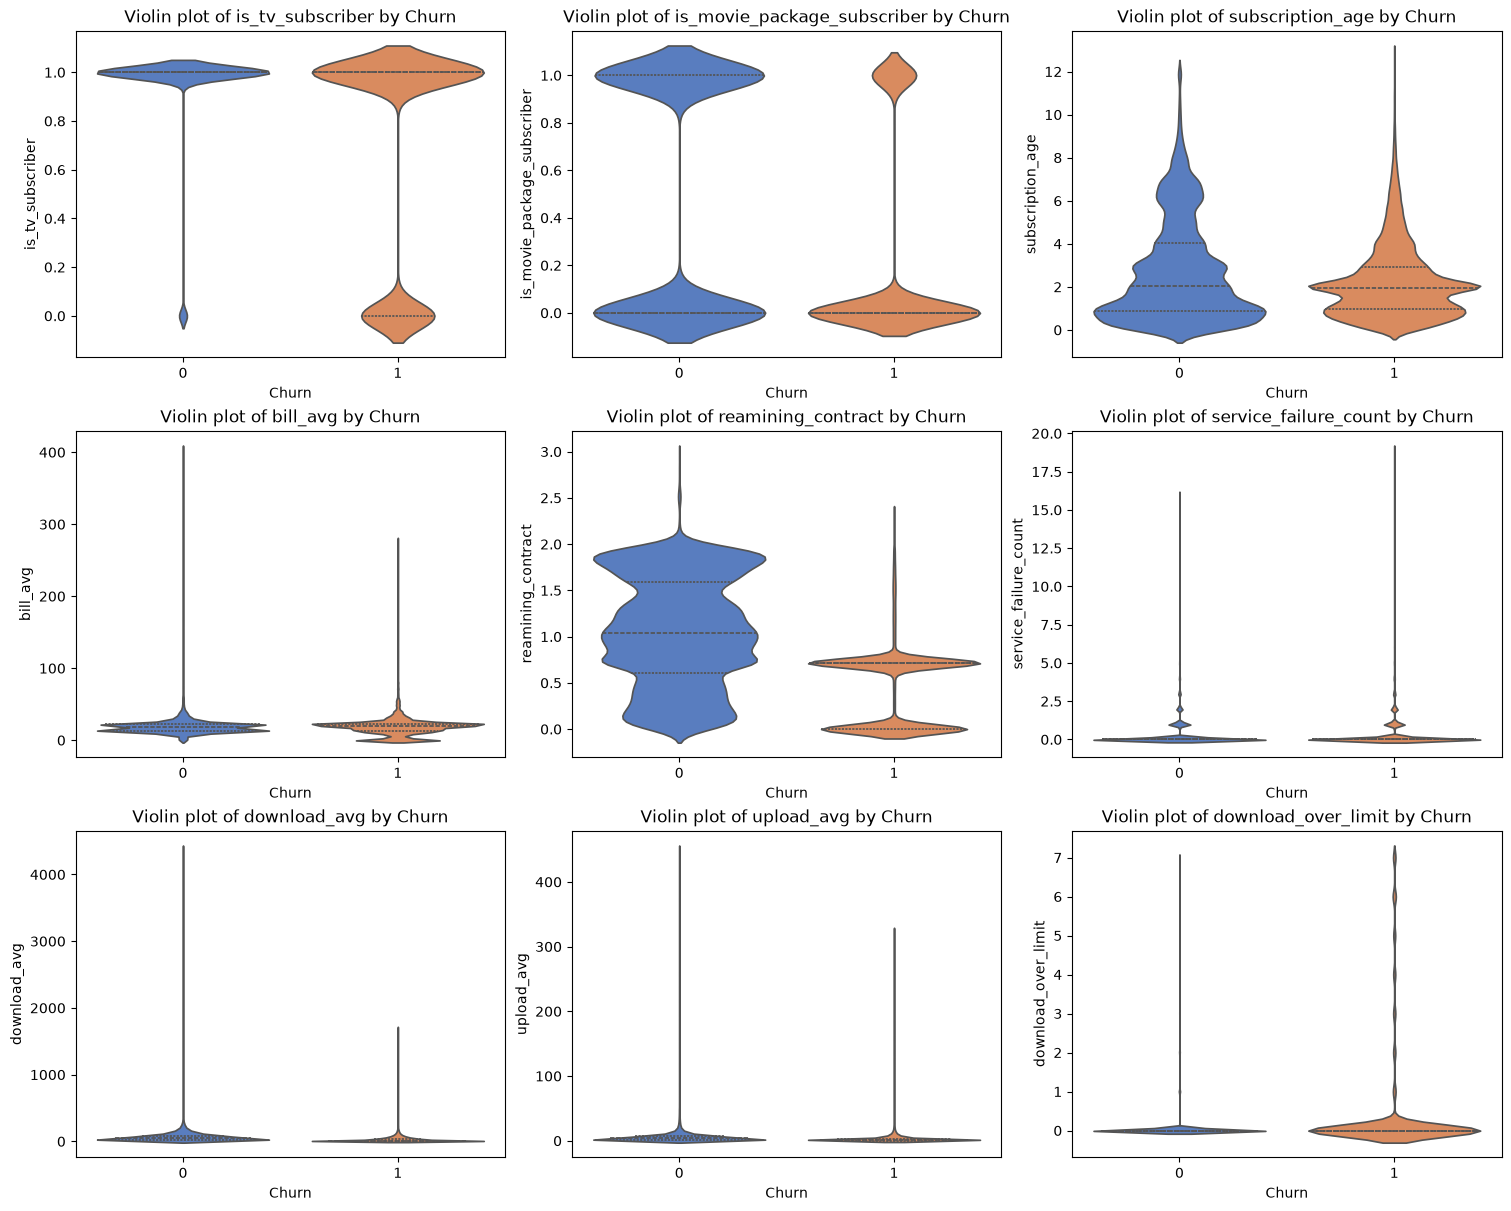

In [20]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), constrained_layout=True)
axes = axes.flatten()

for ax, column in zip(axes, numeric_cols):
    sns.violinplot(data=df, x='churn', y=column, ax=ax, inner='quartile', palette='muted')
    ax.set_title(f'Violin plot of {column} by Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(column)

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.show()

C:\Users\dparh\AppData\Local\Temp\ipykernel_12980\3946382642.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='service_failure_count', y='churn', ax=ax, palette='Blues_d')


Text(0.5, 1.0, 'Churn Rate by Service Failure Count')

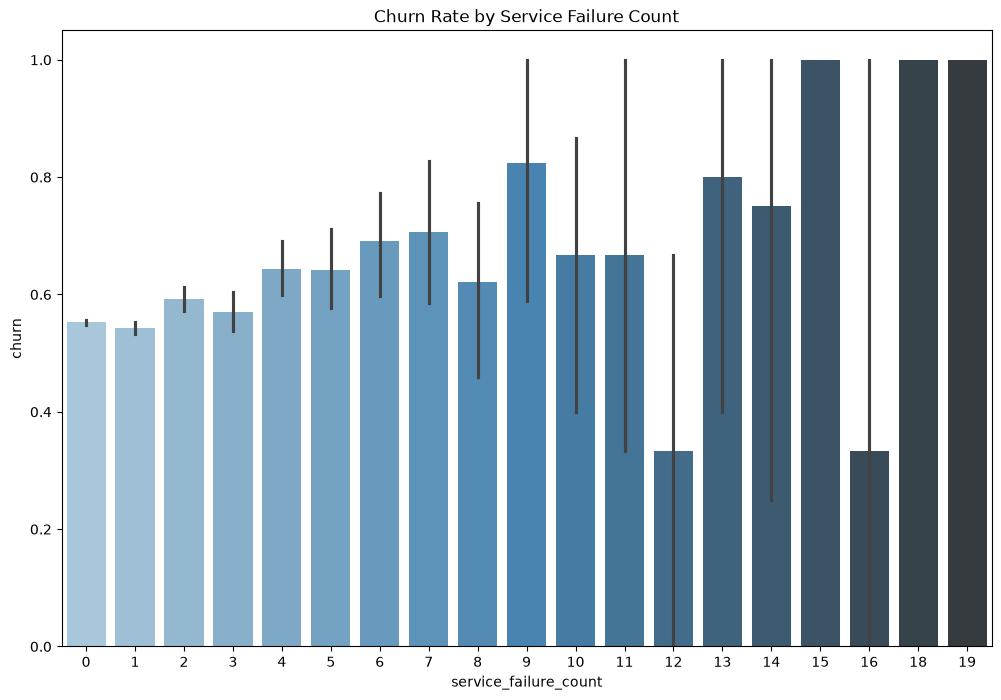

In [21]:
# Churn rate based of failures
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=df, x='service_failure_count', y='churn', ax=ax, palette='Blues_d')
ax.set_title('Churn Rate by Service Failure Count')

### Check for class distribution (importnat during the training process)

Count per class:
churn
1    40050
0    32224
Name: count, dtype: int64

Percentage values:
churn
1    55.41%
0    44.59%
Name: proportion, dtype: str


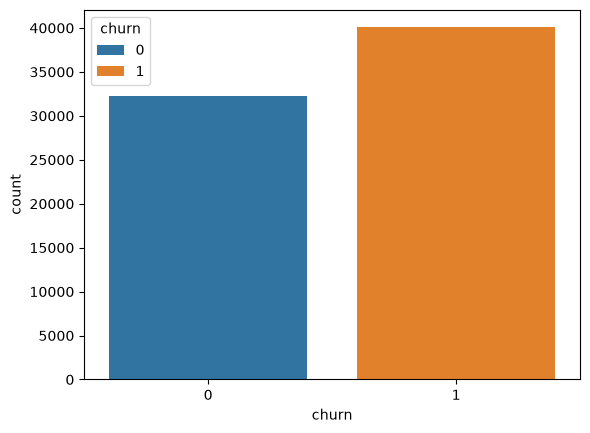

In [23]:
sns.countplot(data=df, x='churn', hue='churn')

counts = df['churn'].value_counts()
pct = df['churn'].value_counts(normalize=True) * 100

print("Count per class:")
print(counts)
print("\nPercentage values:")
print(pct.map("{:.2f}%".format))